In [1]:
!git clone https://github.com/centenohugo/CBMs celeba

Cloning into 'celeba'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 31 (delta 6), reused 29 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 6.51 MiB | 24.23 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
# Data handling
import os

#Pytorch
import torch

# Data transformations and loading
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

# Pretrained models and weights
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


In [3]:
# Define the local route in the colab SSD instance
path = "/content/celeba/resources/data"
os.makedirs(path, exist_ok=True)

# Download images
if not os.path.exists(f"{path}/img_align_celeba.zip"):
    print("Descargando imágenes (Mirror rápido)...")
    !wget -q --show-progress https://cseweb.ucsd.edu/~weijian/static/datasets/celeba/img_align_celeba.zip -O {path}/img_align_celeba.zip

# Download metadata files
urls = [
    "https://raw.githubusercontent.com/KaiserW/bald-recognition/master/dataset/celeba/list_attr_celeba.txt",
    "https://raw.githubusercontent.com/KaiserW/bald-recognition/master/dataset/celeba/list_eval_partition.txt",
    "https://raw.githubusercontent.com/KaiserW/bald-recognition/master/dataset/celeba/list_bbox_celeba.txt",
    "https://raw.githubusercontent.com/KaiserW/bald-recognition/master/dataset/celeba/list_landmarks_align_celeba.txt"
]

for url in urls:
    filename = url.split('/')[-1]
    if not os.path.exists(f"{path}/{filename}"):
        !wget -q {url} -P {path}/

print("Files ready in /content/celeba/ (remote SSD)")

Descargando imágenes (Mirror rápido)...
/content/celeba/res 100%[===================>]   1.34G  14.6MB/s    in 2m 18s  
Files ready in /content/celeba/ (remote SSD)


In [4]:
# Move to the folder where the images are located
%cd /content/celeba/resources/data

# Unzip the file
!unzip -q img_align_celeba.zip

# Verify our structure is /content/celeba/resources/data/000001.jpg, etc.
if os.path.exists('/content/celeba/resources/data/img_align_celeba'):
    print("Expected structure found: /content/celeba/resources/data/img_align_celeba/")
else:
    print("Error: Expected structure not found.")

# Go back to the upper folder
%cd /content


/content/celeba/resources/data
Expected structure found: /content/celeba/resources/data/img_align_celeba/
/content


In [5]:
# Among the 40 feature CelebA has, we will focus on 10, and predict 'Smiling'
CONCEPT_NAMES = [
    'Mouth_Slightly_Open', 'High_Cheekbones', 'Chubby', 'Narrow_Eyes',
    'Bags_Under_Eyes', 'Big_Lips', 'Big_Nose', 'Pointy_Nose',
    'Bushy_Eyebrows', 'Arched_Eyebrows'
]
TARGET_NAME = 'Smiling'

In [6]:
# Go back to the folder where the images and the custom CelebA class are located for dataloader
%cd /content/celeba/resources/data
print("Current working directory:", os.getcwd())

#from celebacustom import CelebACustom
import inspect
from celebacustom import CelebACustom
print(inspect.signature(CelebACustom.__init__))


/content/celeba/resources/data
Current working directory: /content/celeba/resources/data
(self, root, concept_names, target_name, split='train', transform=None)


In [7]:
data_path = "/content/celeba/resources/data"
def get_dataloaders(root_dir=data_path, batch_size=64, num_workers=2):
    """
    Returns train, val, and test dataloaders for CelebA prepared for ResNet-18.
    """
    # Standard ImageNet normalization for ResNet-18
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
    ])

    # Download datasets
    train_ds = CelebACustom(root = root_dir, concept_names=CONCEPT_NAMES, target_name=TARGET_NAME, split='train', transform=transform)
    val_ds = CelebACustom(root = root_dir, concept_names=CONCEPT_NAMES, target_name=TARGET_NAME, split='valid', transform=transform)
    test_ds = CelebACustom(root = root_dir, concept_names=CONCEPT_NAMES, target_name=TARGET_NAME, split='test', transform=transform)

    # Load data into dataloaders
    trainloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    valloader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    testloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return trainloader, valloader, testloader

In [8]:
trainloader, valloader, testloader = get_dataloaders(root_dir=data_path, batch_size=64, num_workers=2)
train_dataset = trainloader.dataset
val_dataset = valloader.dataset
test_dataset = testloader.dataset

print("Train size:", len(train_dataset))
print("Valid size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 162770
Valid size: 19867
Test size: 19962


In [9]:
# Check for the dimensions of the first sample on training dataset

img, concepts, target = train_dataset[0]
print("Image tensor shape:", img.shape)

# Check the concepts and target values
print("Concepts shape:", concepts.shape)
for name, val in zip(CONCEPT_NAMES, concepts):
    print(f"  {name}: {int(val.item())}")
print("Target (Smiling):", int(target.item()))


Image tensor shape: torch.Size([3, 224, 224])
Concepts shape: torch.Size([10])
  Mouth_Slightly_Open: 1
  High_Cheekbones: 1
  Chubby: 0
  Narrow_Eyes: 0
  Bags_Under_Eyes: 0
  Big_Lips: 0
  Big_Nose: 0
  Pointy_Nose: 1
  Bushy_Eyebrows: 0
  Arched_Eyebrows: 1
Target (Smiling): 1


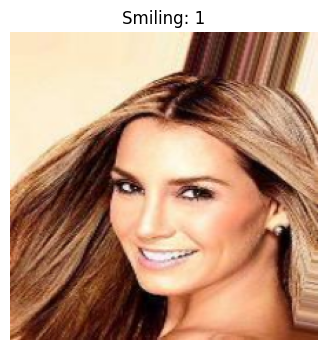

In [10]:
# Visualizar imagen (desnormalizar primero)
import matplotlib.pyplot as plt

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])
img_vis = img * std[:, None, None] + mean[:, None, None]
img_vis = img_vis.clamp(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_vis.permute(1, 2, 0))
plt.title(f"Smiling: {int(target.item())}")
plt.axis("off")
plt.show()

# Models

## Baseline Classifiers (x -> y)

In [11]:
# Hyperparams
lr = 1e-3
epochs = 1

In [12]:
%cd /content/celeba/models

from backbone import Backbone
from baseline_classifier import BaselineClassifier_extended

# Take advantage of cuda GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = Backbone()

my_baseline = BaselineClassifier_extended(backbone=backbone, epochs=epochs, lr=lr)
my_baseline = my_baseline.to(device)

my_baseline.trainloop(trainloader, valloader)


/content/celeba/models
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


Starting training: 1 epochs, lr=0.001, 2544 train batches, 311 val batches, device=cuda:0


Epoch 1/1 — training...
  Epoch 1/1  batch 100/2544  batch loss: 0.2480
  Epoch 1/1  batch 200/2544  batch loss: 0.2086
  Epoch 1/1  batch 300/2544  batch loss: 0.1990
  Epoch 1/1  batch 400/2544  batch loss: 0.2121
  Epoch 1/1  batch 500/2544  batch loss: 0.1734
  Epoch 1/1  batch 600/2544  batch loss: 0.1388
  Epoch 1/1  batch 700/2544  batch loss: 0.2764
  Epoch 1/1  batch 800/2544  batch loss: 0.2950
  Epoch 1/1  batch 900/2544  batch loss: 0.1672
  Epoch 1/1  batch 1000/2544  batch loss: 0.1781
  Epoch 1/1  batch 1100/2544  batch loss: 0.1041
  Epoch 1/1  batch 1200/2544  batch loss: 0.2130
  Epoch 1/1  batch 1300/2544  batch loss: 0.2893
  Epoch 1/1  batch 1400/2544  batch loss: 0.1513
  Epoch 1/1  batch 1500/2544  batch loss: 0.1226
  Epoch 1/1  batch 1600/2544  batch loss: 0.1740
  Epoch 1/1  batch 1700/2544  batch loss: 0.1347
  Epoch 1/1  batch 1800/2544  batch loss: 0.0498
  Epoch 1/1

In [13]:
import torch
from sklearn.metrics import accuracy_score, roc_auc_score

my_baseline.eval()

all_y_true, all_y_pred, all_y_probs = [], [], []

with torch.no_grad():
    for x, _, y in testloader:
        x, y = x.to(device), y.to(device)

        logits = my_baseline(x)
        probs = torch.sigmoid(logits).squeeze(1)# As the model ends with nn.Linear
                                                # which returns a logit and we need
                                                # to match it with a probability
        preds = (probs > 0.5).float()

        all_y_true.append(y.cpu())
        all_y_pred.append(preds.cpu())
        all_y_probs.append(probs.cpu())

y_true = torch.cat(all_y_true).numpy()
y_pred = torch.cat(all_y_pred).numpy()
y_probs = torch.cat(all_y_probs).numpy()

print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Test AUROC:    {roc_auc_score(y_true, y_probs):.4f}")


Test Accuracy: 0.9264
Test AUROC:    0.9809


## Concept Predictor (x -> c)

In [14]:
# Hyperparams
lr = 1e-3
epochs = 1

Firs approach. A bit naive as we assume all concepts have the same frequency and their prediction is representative.

In [15]:
%cd /content/celeba/models

from backbone import Backbone
from concept_predictor import ConceptPredictor_extended

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = Backbone()

my_concept_predictor = ConceptPredictor_extended(backbone=backbone, num_concepts=10, epochs=epochs, lr=lr)
my_concept_predictor = my_concept_predictor.to(device)

my_concept_predictor.trainloop(trainloader, valloader)

/content/celeba/models
Starting training: 1 epochs, lr=0.001, 2544 train batches, 311 val batches, device=cuda:0


Epoch 1/1 — training...
  Epoch 1/1  batch 100/2544  batch loss: 0.3327
  Epoch 1/1  batch 200/2544  batch loss: 0.3479
  Epoch 1/1  batch 300/2544  batch loss: 0.3489
  Epoch 1/1  batch 400/2544  batch loss: 0.2838
  Epoch 1/1  batch 500/2544  batch loss: 0.3309
  Epoch 1/1  batch 600/2544  batch loss: 0.2767
  Epoch 1/1  batch 700/2544  batch loss: 0.2940
  Epoch 1/1  batch 800/2544  batch loss: 0.3176
  Epoch 1/1  batch 900/2544  batch loss: 0.3122
  Epoch 1/1  batch 1000/2544  batch loss: 0.2950
  Epoch 1/1  batch 1100/2544  batch loss: 0.3117
  Epoch 1/1  batch 1200/2544  batch loss: 0.3286
  Epoch 1/1  batch 1300/2544  batch loss: 0.3072
  Epoch 1/1  batch 1400/2544  batch loss: 0.2769
  Epoch 1/1  batch 1500/2544  batch loss: 0.3205
  Epoch 1/1  batch 1600/2544  batch loss: 0.3044
  Epoch 1/1  batch 1700/2544  batch loss: 0.2941
  Epoch 1/1  batch 1800/2544  batch l

In [16]:
#Evaluation per concept.

from sklearn.metrics import accuracy_score, f1_score
import numpy as np

my_concept_predictor.eval()

all_c_true, all_c_pred = [], []

with torch.no_grad():
    for x, c, _ in testloader:
        x = x.to(device)
        logits = my_concept_predictor(x)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_c_true.append(c.cpu())
        all_c_pred.append(preds.cpu())

c_true = torch.cat(all_c_true).numpy()   # shape (N, 10)
c_pred = torch.cat(all_c_pred).numpy()   # shape (N, 10)

print(f"{'Concept':<25} {'Accuracy':>10} {'F1':>10}")
print("-" * 47)
for i, name in enumerate(CONCEPT_NAMES):
    acc = accuracy_score(c_true[:, i], c_pred[:, i])
    f1  = f1_score(c_true[:, i], c_pred[:, i])
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")

print("-" * 47)
print(f"{'Macro Average':<25} {np.mean([accuracy_score(c_true[:,i], c_pred[:,i]) for i in range(10)]):>10.4f} "
      f"{f1_score(c_true, c_pred, average='macro'):>10.4f}")

Concept                     Accuracy         F1
-----------------------------------------------
Mouth_Slightly_Open           0.9358     0.9361
High_Cheekbones               0.8618     0.8618
Chubby                        0.9530     0.2600
Narrow_Eyes                   0.8764     0.4658
Bags_Under_Eyes               0.8500     0.5641
Big_Lips                      0.7125     0.3694
Big_Nose                      0.8439     0.5594
Pointy_Nose                   0.7557     0.5736
Bushy_Eyebrows                0.9261     0.6736
Arched_Eyebrows               0.8307     0.7114
-----------------------------------------------
Macro Average                 0.8546     0.5975


See how frequent are each of our concepts in our dateset to decide whether it makes sense to apply class weighting or not.

Disclaimer: we will decide based on our train set, assuming it is a representative data set.

In [17]:
all_c = []
for _, c, _ in trainloader:
    all_c.append(c)

all_c = torch.cat(all_c, dim=0).numpy()  # shape (162770, 10)

print(f"{'Concept':<25} {'Positives':>10} {'Total':>10} {'% Positive':>12}")
print("-" * 60)
for i, name in enumerate(CONCEPT_NAMES):
    pos = all_c[:, i].sum()
    total = len(all_c)
    print(f"{name:<25} {int(pos):>10} {total:>10} {100*pos/total:>11.1f}%")

Concept                    Positives      Total   % Positive
------------------------------------------------------------
Mouth_Slightly_Open            78486     162770        48.2%
High_Cheekbones                73645     162770        45.2%
Chubby                          9389     162770         5.8%
Narrow_Eyes                    18869     162770        11.6%
Bags_Under_Eyes                33280     162770        20.4%
Big_Lips                       39213     162770        24.1%
Big_Nose                       38341     162770        23.6%
Pointy_Nose                    44846     162770        27.6%
Bushy_Eyebrows                 23386     162770        14.4%
Arched_Eyebrows                43278     162770        26.6%


Create positional weights to balance concepts. The more imbalanced are 'Chubby' 'Narrow Eyes' and 'Bushy Eyebrows'

In [18]:
pos = all_c.sum(axis=0)
neg = len(all_c) - pos
pos_weight = neg / pos

# Parse it into a tensor and move it to the GPU memory
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

print(f"{'Concept':<25} {'pos_weight':>12}")
print("-" * 38)
for name, w in zip(CONCEPT_NAMES, pos_weight):
    print(f"{name:<25} {w:>12.2f}")

Concept                     pos_weight
--------------------------------------
Mouth_Slightly_Open               1.07
High_Cheekbones                   1.21
Chubby                           16.34
Narrow_Eyes                       7.63
Bags_Under_Eyes                   3.89
Big_Lips                          3.15
Big_Nose                          3.25
Pointy_Nose                       2.63
Bushy_Eyebrows                    5.96
Arched_Eyebrows                   2.76


Train new model which considers positional weights

In [29]:
%cd /content/celeba/models

from backbone import Backbone
from concept_predictor import ConceptPredictor_extended

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

backbone = Backbone()

my_concept_predictor_pos_weights = ConceptPredictor_extended(backbone=backbone,
                                                 num_concepts=10, epochs=epochs, lr=lr, pos_weight = pos_weight_tensor)
my_concept_predictor_pos_weights = my_concept_predictor_pos_weights.to(device)

my_concept_predictor_pos_weights.trainloop(trainloader, valloader)

/content/celeba/models
Starting training: 1 epochs, lr=0.001, 2544 train batches, 311 val batches, device=cuda:0


Epoch 1/1 — training...
  Epoch 1/1  batch 100/2544  batch loss: 0.7694
  Epoch 1/1  batch 200/2544  batch loss: 0.7170
  Epoch 1/1  batch 300/2544  batch loss: 0.6766
  Epoch 1/1  batch 400/2544  batch loss: 0.6409
  Epoch 1/1  batch 500/2544  batch loss: 0.6186
  Epoch 1/1  batch 600/2544  batch loss: 0.6013
  Epoch 1/1  batch 700/2544  batch loss: 0.6314
  Epoch 1/1  batch 800/2544  batch loss: 0.5490
  Epoch 1/1  batch 900/2544  batch loss: 0.5848
  Epoch 1/1  batch 1000/2544  batch loss: 0.5626
  Epoch 1/1  batch 1100/2544  batch loss: 0.6040
  Epoch 1/1  batch 1200/2544  batch loss: 0.6557
  Epoch 1/1  batch 1300/2544  batch loss: 0.6773
  Epoch 1/1  batch 1400/2544  batch loss: 0.5838
  Epoch 1/1  batch 1500/2544  batch loss: 0.5768
  Epoch 1/1  batch 1600/2544  batch loss: 0.6460
  Epoch 1/1  batch 1700/2544  batch loss: 0.6662
  Epoch 1/1  batch 1800/2544  batch l

In [30]:
# Save results from model without pos_weight
c_true_no_w = c_true.copy()
c_pred_no_w = c_pred.copy()

In [31]:
# Evaluate model with pos_weight
my_concept_predictor_pos_weights.eval()

all_c_true, all_c_pred = [], []

with torch.no_grad():
    for x, c, _ in testloader:
        x = x.to(device)
        logits = my_concept_predictor_pos_weights(x)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_c_true.append(c.cpu())
        all_c_pred.append(preds.cpu())

c_true_w = torch.cat(all_c_true).numpy()
c_pred_w = torch.cat(all_c_pred).numpy()

# Comparison table
print(f"{'Concept':<25} {'Acc (no w)':>12} {'F1 (no w)':>11} {'Acc (w)':>10} {'F1 (w)':>10}")
print("-" * 70)
for i, name in enumerate(CONCEPT_NAMES):
    acc_nw = accuracy_score(c_true_no_w[:, i], c_pred_no_w[:, i])
    f1_nw  = f1_score(c_true_no_w[:, i], c_pred_no_w[:, i])
    acc_w  = accuracy_score(c_true_w[:, i], c_pred_w[:, i])
    f1_w   = f1_score(c_true_w[:, i], c_pred_w[:, i])
    print(f"{name:<25} {acc_nw:>12.4f} {f1_nw:>11.4f} {acc_w:>10.4f} {f1_w:>10.4f}")

print("-" * 70)
print(f"{'Macro Average':<25}"
      f" {np.mean([accuracy_score(c_true_no_w[:,i], c_pred_no_w[:,i]) for i in range(10)]):>12.4f}"
      f" {f1_score(c_true_no_w, c_pred_no_w, average='macro'):>11.4f}"
      f" {np.mean([accuracy_score(c_true_w[:,i], c_pred_w[:,i]) for i in range(10)]):>10.4f}"
      f" {f1_score(c_true_w, c_pred_w, average='macro'):>10.4f}")

Concept                     Acc (no w)   F1 (no w)    Acc (w)     F1 (w)
----------------------------------------------------------------------
Mouth_Slightly_Open             0.9358      0.9361     0.9351     0.9337
High_Cheekbones                 0.8618      0.8618     0.8673     0.8629
Chubby                          0.9530      0.2600     0.7981     0.3292
Narrow_Eyes                     0.8764      0.4658     0.8229     0.5292
Bags_Under_Eyes                 0.8500      0.5641     0.8104     0.6398
Big_Lips                        0.7125      0.3694     0.6350     0.5737
Big_Nose                        0.8439      0.5594     0.7494     0.5832
Pointy_Nose                     0.7557      0.5736     0.6698     0.5880
Bushy_Eyebrows                  0.9261      0.6736     0.9019     0.6708
Arched_Eyebrows                 0.8307      0.7114     0.8169     0.7189
----------------------------------------------------------------------
Macro Average                   0.8546      0.5975     

As expected by weighting the concepts we improve F1 and reduce accuracy, as we force the model to detect more positives, reducing false negatives and increasing false positives.

In this case we could conclude weighting was of little helped. We are now more prone to errors (our new accuracy is lower), but we detected better what were previously considered unbalanced or rare cases (e.g. a case were the concept chubby and narrow eyes are present)